In [1]:
import re
import numpy as np
import pandas as pd
from sys import argv
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.colors import LogNorm, LinearSegmentedColormap


def get_preds(fname): # "get predictions"
    preds = []
    fh = open(fname)

    for line in fh:
        v = line.rstrip().split() 
        preds.append([v[0], float(v[1]), int(v[2])]) # extracting the name of the protein, name of the best match and the e-value
    return preds

def get_cm(preds, th = 0.001): # 'get confusion matrix'
    cm = np.zeros((2,2))
    n = len(preds)
    for k in range(n):
        j = 0
        i = preds[k][2]
        
        if len(preds[k]) < 3: continue
        if float(preds[k][1]) <= th: 
            j=1 
        else: j=0
        cm[i,j]=cm[i,j]+1
    return cm


def get_acc(cm): # 'get accuracy'
    total=np.sum(cm)
    return (cm[0,0] + cm[1,1])/total 


def get_mcc(cm):   #Matthew correlation coefficient 
    tp = cm [1,1]  #True Positives
    tn = cm[0,0]   #True Negatives
    fn = cm[1,0]   #False Negatives 
    fp = cm[0,1]   #False Positives 
    
    numerator = (tp *tn)-(fp*fn)
    d=(tp + fp) * (tp + fn) * (tn +fp) * (tn +fn) #Calculate the denominator 
    mcc=numerator/np.sqrt(d)
    return mcc


In [2]:
#Plot confusion matrix for Kunitz_set1

def plot_confusion_matrix(file, th):

    colors = ["#fdf5e6", "#8b4513", "#008080"] # Crema -> Marrone -> Verde Acqua
    my_cmap = LinearSegmentedColormap.from_list("MarroneVerdeAcqua", colors)

    preds = get_preds(file)
    cm = get_cm(preds, th)

    sns.set_style("white") # Rimuove la griglia grigia di sfondo
    plt.figure(figsize=(7, 5))

    ax = sns.heatmap(cm, 
                     fmt='g', 
                     cmap=my_cmap, # Usiamo la nostra palette custom
                     norm=LogNorm(vmin=1, vmax=cm.max()), 
                     xticklabels=['Predicted Negative', 'Predicted Positive'],
                     yticklabels=['Actual Negative', 'Actual Positive'],
                    )

    #Custom labels
    cell_labels = [
        ['TN', 'FP'],
        ['FN', 'TP']
    ]

    for i in range(2):
        for j in range(2):

            #(TP/TN/FP/FN)
            ax.text(
                j + 0.5,
                i + 0.35,
                cell_labels[i][j],
                ha='center',
                va='center',
                fontsize=16,
                fontweight='bold',
                color='grey'   
            )

            #Numerical value
            ax.text(
                j + 0.5,
                i + 0.65,
                f"{cm[i,j]}",
                ha='center',
                va='center',
                fontsize=13,
                fontweight='bold',
                color='grey'  
            )

    ax.grid(False) 
    plt.title(f'{file} (TH: {th})', fontsize=12, pad=20)
    plt.savefig('CM.png', dpi=300)
    plt.show()

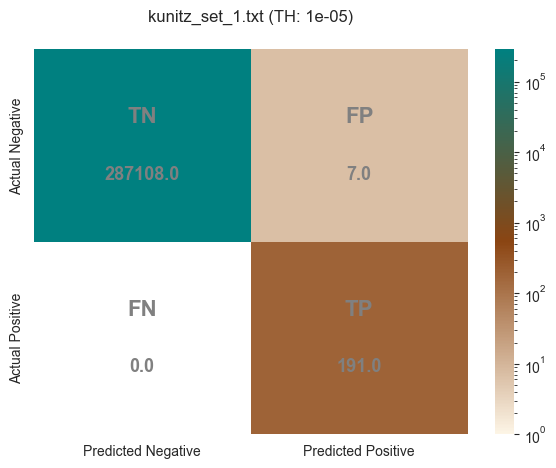

In [3]:
plot_confusion_matrix("kunitz_set_1.txt", 1e-5)

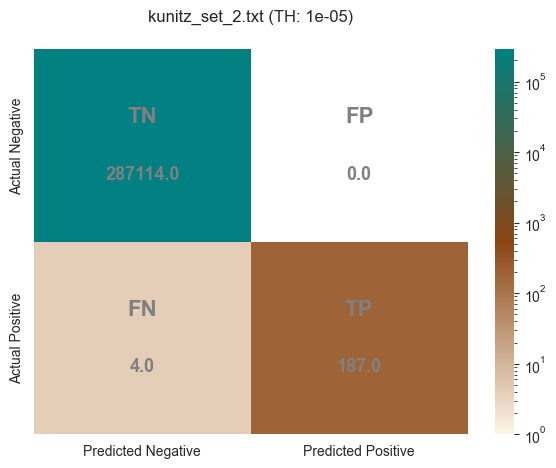

In [4]:
plot_confusion_matrix("kunitz_set_2.txt", 1e-5)